## EDA Basics Assignment

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("House Price India.csv")
print(df.head())

           id   Date  number of bedrooms  number of bathrooms  living area  \
0  6762810145  42491                   5                 2.50         3650   
1  6762810635  42491                   4                 2.50         2920   
2  6762810998  42491                   5                 2.75         2910   
3  6762812605  42491                   4                 2.50         3310   
4  6762812919  42491                   3                 2.00         2710   

   lot area  number of floors  waterfront present  number of views  \
0      9050               2.0                   0                4   
1      4000               1.5                   0                0   
2      9480               1.5                   0                0   
3     42998               2.0                   0                0   
4      4500               1.5                   0                0   

   condition of the house  ...  Built Year  Renovation Year  Postal Code  \
0                       5  ...    

In [25]:
df.info() #Dataset Information
df.describe() #Statistical Summary
print(df.isnull().sum()) #Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True) #If missing values exist

<class 'pandas.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Area of the h

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,6762830250,42734,2,1.50,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14616,6762830339,42734,3,2.00,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14617,6762830618,42734,2,1.00,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14618,6762830709,42734,4,1.00,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000


Q1. What is the average, median, and standard deviation of house prices?

In [26]:
print("Average Price:", df["Price"].mean())
print("Median Price:", df["Price"].median())
print("Standard Deviation:", df["Price"].std())


Average Price: 538932.2183310534
Median Price: 450000.0
Standard Deviation: 367532.38080396695


Q2. Which number of bedrooms is most common?

In [27]:
modes = df["number of bedrooms"].mode()
print("Most common number of bedrooms:")
for mode in modes:
    print(mode)

Most common number of bedrooms:
3


Q3. Check if the price data is skewed.

In [28]:
print("Price Skewness:", df["Price"].skew())

Price Skewness: 4.269297720707117


Q4. What is the average price for each number of bedrooms?



In [29]:
avg_price_by_bedrooms = df.groupby("number of bedrooms")["Price"].mean()
print(avg_price_by_bedrooms)

number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: Price, dtype: float64


Q5.  What is the relationship between living area and price? (Use : Area without Basement).

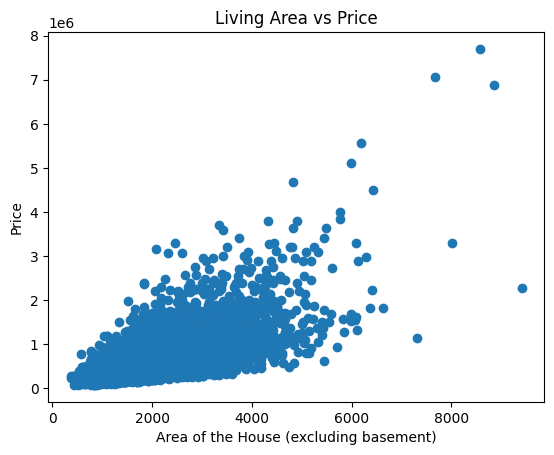

In [30]:
plt.scatter(df["Area of the house(excluding basement)"], df["Price"])
plt.xlabel("Area of the House (excluding basement)")
plt.ylabel("Price")
plt.title("Living Area vs Price")
plt.show()

Interpretation: This scatter plot shows that bigger homes tend to have higher prices

In [31]:
print(df["Area of the house(excluding basement)"].corr(df["Price"])) # correlation

0.6152204198678107


Q6. Identify any anomalies where houses have high prices but low areas.

In [32]:
high_price = df["Price"].quantile(0.90)
low_area = df["Area of the house(excluding basement)"].quantile(0.10)

anomalies = df[(df["Price"] > high_price) & (df["Area of the house(excluding basement)"] < low_area)]
print(anomalies)

              id   Date  number of bedrooms  number of bathrooms  living area  \
8517  6762811560  42621                   3                 1.75         1810   

      lot area  number of floors  waterfront present  number of views  \
8517     24586               1.0                   0                4   

      condition of the house  ...  Built Year  Renovation Year  Postal Code  \
8517                       4  ...        1983                0       122057   

      Lattitude  Longitude  living_area_renov  lot_area_renov  \
8517    52.7614   -114.412               3540           14200   

      Number of schools nearby  Distance from the airport   Price  
8517                         2                         55  990000  

[1 rows x 23 columns]


Interpretation: These are unusual properties—expensive but very small. They may be in exclusive locations or have special features.

Q7. Compare average price based on number of floors and houses with or without waterfront.

In [33]:
avg_price_by_floors = df.groupby("number of floors")["Price"].mean()
print(avg_price_by_floors)

avg_price_waterfront = df.groupby("waterfront present")["Price"].mean()
print(avg_price_waterfront)

number of floors
1.0    4.369769e+05
1.5    5.549301e+05
2.0    6.487372e+05
2.5    1.106233e+06
3.0    5.663281e+05
3.5    1.205875e+06
Name: Price, dtype: float64
waterfront present
0    5.304174e+05
1    1.641902e+06
Name: Price, dtype: float64


Interpretation: Compare average prices by number of floors and also by whether the property is on the waterfront.

Q8. Identify the minimum and maximum house price. What does this indicate?

In [34]:
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())

Minimum Price: 78000
Maximum Price: 7700000


Interpretation: This shows the cheapest and most expensive properties—useful for seeing price range extremes.

Q9. Which location (zipcode/area) has the highest average price?

In [35]:
avg_price_by_zip = df.groupby("Postal Code")["Price"].mean()
print(avg_price_by_zip.sort_values(ascending=False).head())

Postal Code
122071    2.348311e+06
122048    1.296414e+06
122057    1.188517e+06
122047    1.069295e+06
122061    8.895896e+05
Name: Price, dtype: float64


Q10. Write at least 5 insights from your analysis.

1.House prices are positively skewed, meaning a few expensive properties inflate the average.

2.Most homes have 3 bedrooms, making it the most common bedroom count.

3 Bigger living areas tend to lead to higher prices, as seen in the scatter plot.

4.Waterfront properties are significantly pricier than others.

5 Zipcode 122071 has the highest average price, indicating it is the most expensive area.